# identifying or predicting the Attrition of employee by using this dataset

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("employee_attrition_dataset.csv")
df.head()

,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


## target variable is Attrition

In [7]:
print("size of dataset",df.size, "\n","null values in dataset",df.isnull().sum())
print("shape of dataset",df.shape)


size of dataset 26000 
 null values in dataset Employee_ID                      0
Age                              0
Gender                           0
Marital_Status                   0
Department                       0
Job_Role                         0
Job_Level                        0
Monthly_Income                   0
Hourly_Rate                      0
Years_at_Company                 0
Years_in_Current_Role            0
Years_Since_Last_Promotion       0
Work_Life_Balance                0
Job_Satisfaction                 0
Performance_Rating               0
Training_Hours_Last_Year         0
Overtime                         0
Project_Count                    0
Average_Hours_Worked_Per_Week    0
Absenteeism                      0
Work_Environment_Satisfaction    0
Relationship_with_Manager        0
Job_Involvement                  0
Distance_From_Home               0
Number_of_Companies_Worked       0
Attrition                        0
dtype: int64
shape of dataset (1000, 26)


In [6]:
print("duplicate values in dataset",df.duplicated())


duplicate values in dataset 0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool


In [8]:
print("checking dtypes and other desc info",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64 
 13  Job_

### so there are no null values and duplicated values in dataset. if there are any null values are dupicaten
### values we use (df.dropna() or df.fillna()) operations to fill or remove the null values . and for duplicate values we use df.drop_duplicates() function to remove the duplicates . 

In [10]:
print("statistic info about dataset","\n", df.describe())

statistic info about dataset 
        Employee_ID          Age    Job_Level  Monthly_Income  Hourly_Rate  \
count  1000.000000  1000.000000  1000.000000     1000.000000  1000.000000   
mean    500.500000    39.991000     3.055000    11499.899000    57.837000   
std     288.819436    11.780055     1.399977     4920.529231    24.702037   
min       1.000000    20.000000     1.000000     3001.000000    15.000000   
25%     250.750000    30.000000     2.000000     7395.750000    36.000000   
50%     500.500000    41.000000     3.000000    11256.000000    58.000000   
75%     750.250000    50.250000     4.000000    15855.000000    80.000000   
max    1000.000000    59.000000     5.000000    19999.000000    99.000000   

       Years_at_Company  Years_in_Current_Role  Years_Since_Last_Promotion  \
count       1000.000000            1000.000000                  1000.00000   
mean          14.922000               7.539000                     4.40800   
std            8.350548               4.0

### checking unique, and counting the frequency of each category

In [13]:
print("unique values","\n","Marital_Status:", df['Marital_Status'].unique(),"\n","Gender:",df['Gender'].unique(),
      "\n","Department",df['Department'].unique(),"\n","Job_Role:",df["Job_Role"].unique(),"\n","Overtime",df["Overtime"].unique())

unique values 
 Marital_Status: ['Married' 'Divorced' 'Single'] 
 Gender: ['Female' 'Male'] 
 Department ['IT' 'Sales' 'Marketing' 'Finance' 'HR'] 
 Job_Role: ['Manager' 'Assistant' 'Executive' 'Analyst'] 
 Overtime ['No' 'Yes']


In [17]:
print("frequency count","\n","Marital_Status:", df['Marital_Status'].value_counts(),"\n\n","Gender:",df['Gender'].value_counts(),
      "\n","Department",df['Department'].value_counts(),"\n\n","Job_Role:",df["Job_Role"].value_counts(),"\n\n","Overtime",df["Overtime"].value_counts())

frequency count 
 Marital_Status: Marital_Status
Married     348
Single      339
Divorced    313
Name: count, dtype: int64 

 Gender: Gender
Male      516
Female    484
Name: count, dtype: int64 
 Department Department
Finance      218
HR           211
Sales        199
Marketing    198
IT           174
Name: count, dtype: int64 

 Job_Role: Job_Role
Manager      268
Executive    252
Analyst      251
Assistant    229
Name: count, dtype: int64 

 Overtime Overtime
No     512
Yes    488
Name: count, dtype: int64


In [59]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["Attrition"]=le.fit_transform(df['Attrition'])
df['Attrition']

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: Attrition, Length: 1000, dtype: int64

### ploting graphs only for numerical data values to check outliers, spread and skewness

In [60]:
datas=df.select_dtypes(include=np.number)
datas

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,1,15488,28,15,4,2,1,3,...,14,6,54,17,4,4,4,20,3,0
1,2,48,5,13079,28,6,9,1,2,1,...,6,2,45,1,4,1,2,25,2,0
2,3,34,1,13744,24,24,14,8,3,2,...,77,6,34,2,3,4,4,45,3,0
3,4,27,1,6809,26,10,8,2,3,5,...,49,9,48,18,2,3,1,35,3,0
4,5,40,1,10206,52,29,10,1,2,5,...,64,3,33,0,4,1,3,44,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,2,4172,76,24,14,3,4,5,...,76,4,46,10,3,1,4,24,4,0
996,997,47,4,11007,71,19,6,0,3,1,...,53,7,36,16,3,2,4,39,3,1
997,998,50,1,4641,43,25,12,3,4,1,...,7,1,46,9,2,3,3,33,2,0
998,999,28,4,19855,92,13,13,0,2,2,...,54,4,52,17,4,1,4,41,4,0


In [42]:

data = df[['Age', 'Job_Level', 'Years_at_Company', 'Work_Life_Balance', 'Performance_Rating', 'Training_Hours_Last_Year','Project_Count','Average_Hours_Worked_Per_Week','Relationship_with_Manager','Job_Involvement','Number_of_Companies_Worked']]
data

,Age,Job_Level,Years_at_Company,Work_Life_Balance,Performance_Rating,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Relationship_with_Manager,Job_Involvement,Number_of_Companies_Worked
0,58,1,15,1,4,14,6,54,4,4,3
1,48,5,6,2,1,6,2,45,1,2,2
2,34,1,24,3,1,77,6,34,4,4,3
3,27,1,10,3,4,49,9,48,3,1,3
4,40,1,29,2,1,64,3,33,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...
995,27,2,24,4,4,76,4,46,1,4,4
996,47,4,19,3,1,53,7,36,2,4,3
997,50,1,25,4,1,7,1,46,3,3,2
998,28,4,13,2,2,54,4,52,1,4,4


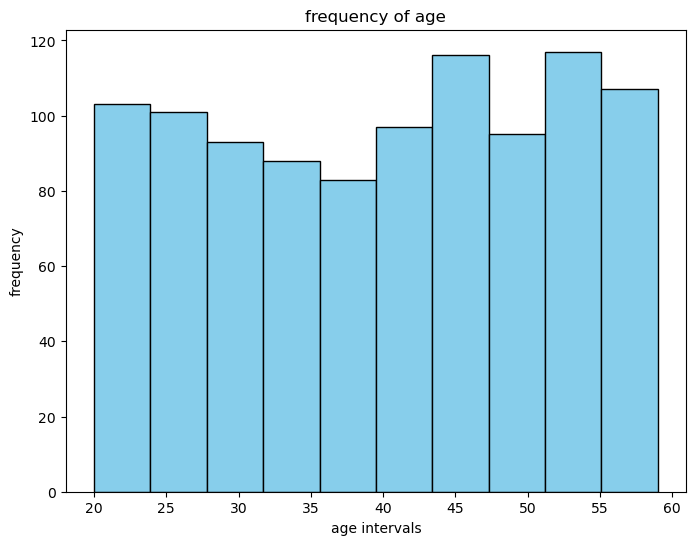

In [20]:
plt.figure(figsize=(8,6))
plt.hist(df['Age'],bins=10,color='skyblue',edgecolor='black')
plt.title("frequency of age")
plt.xlabel("age intervals")
plt.ylabel("frequency")
plt.show()

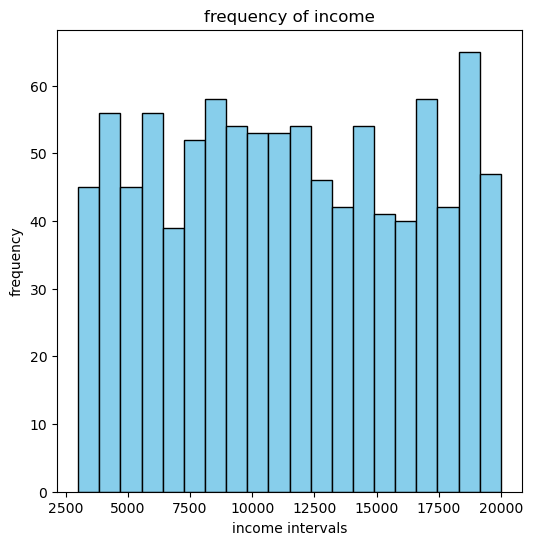

In [22]:
plt.figure(figsize=(6,6))
plt.hist(df['Monthly_Income'],bins=20,color='skyblue',edgecolor='black')
plt.title("frequency of income")
plt.xlabel("income intervals")
plt.ylabel("frequency")
plt.show()

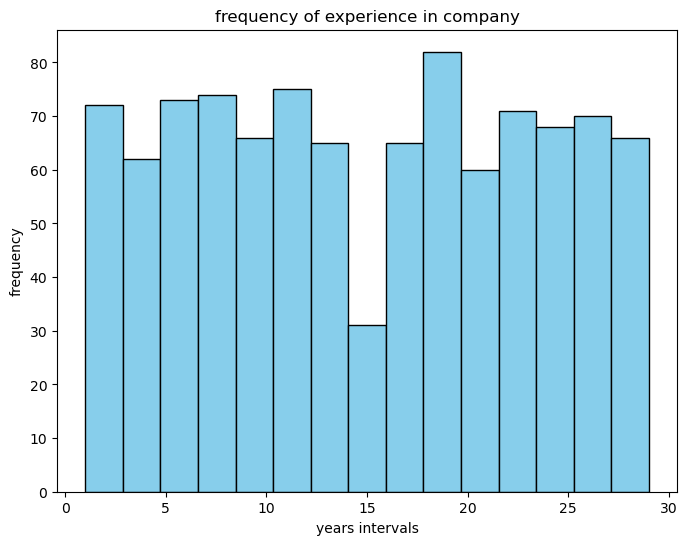

In [24]:
plt.figure(figsize=(8,6))
plt.hist(df['Years_at_Company'],bins=15,color='skyblue',edgecolor='black')
plt.title("frequency of experience in company")
plt.xlabel("years intervals")
plt.ylabel("frequency")
plt.show()

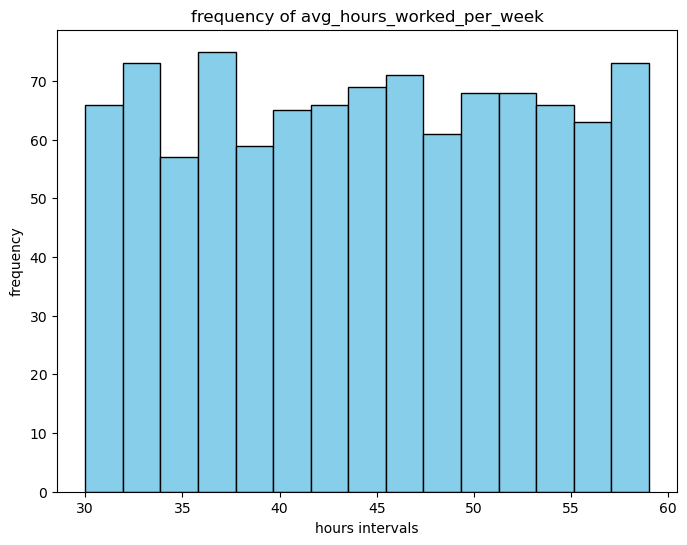

In [69]:
plt.figure(figsize=(8,6))
plt.hist(df['Average_Hours_Worked_Per_Week'],bins=15,color='skyblue',edgecolor='black')
plt.title("frequency of avg_hours_worked_per_week")
plt.xlabel("hours intervals")
plt.ylabel("frequency")
plt.show()

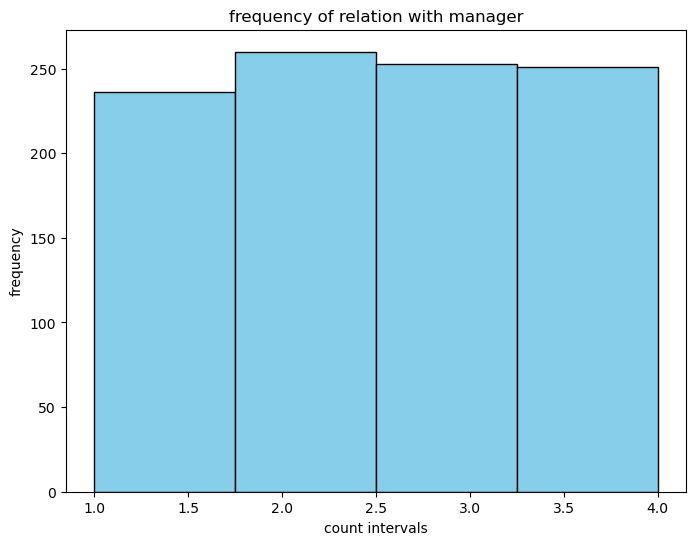

In [72]:
plt.figure(figsize=(8,6))
plt.hist(df['Relationship_with_Manager'],bins=4,color='skyblue',edgecolor='black')
plt.title("frequency of relation with manager")
plt.xlabel("count intervals")
plt.ylabel("frequency")
plt.show()

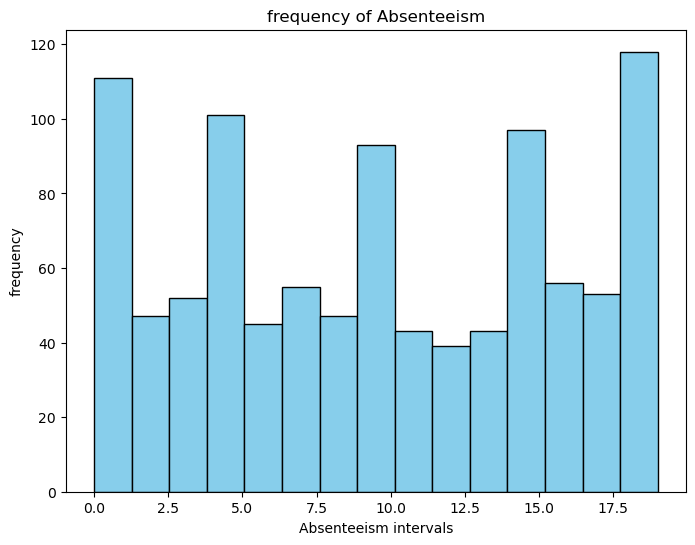

In [73]:
plt.figure(figsize=(8,6))
plt.hist(df['Absenteeism'],bins=15,color='skyblue',edgecolor='black')
plt.title("frequency of Absenteeism")
plt.xlabel("Absenteeism intervals")
plt.ylabel("frequency")
plt.show()

### after observing some positively related variables of targert variable we conclude that there are no skeewness in dataset

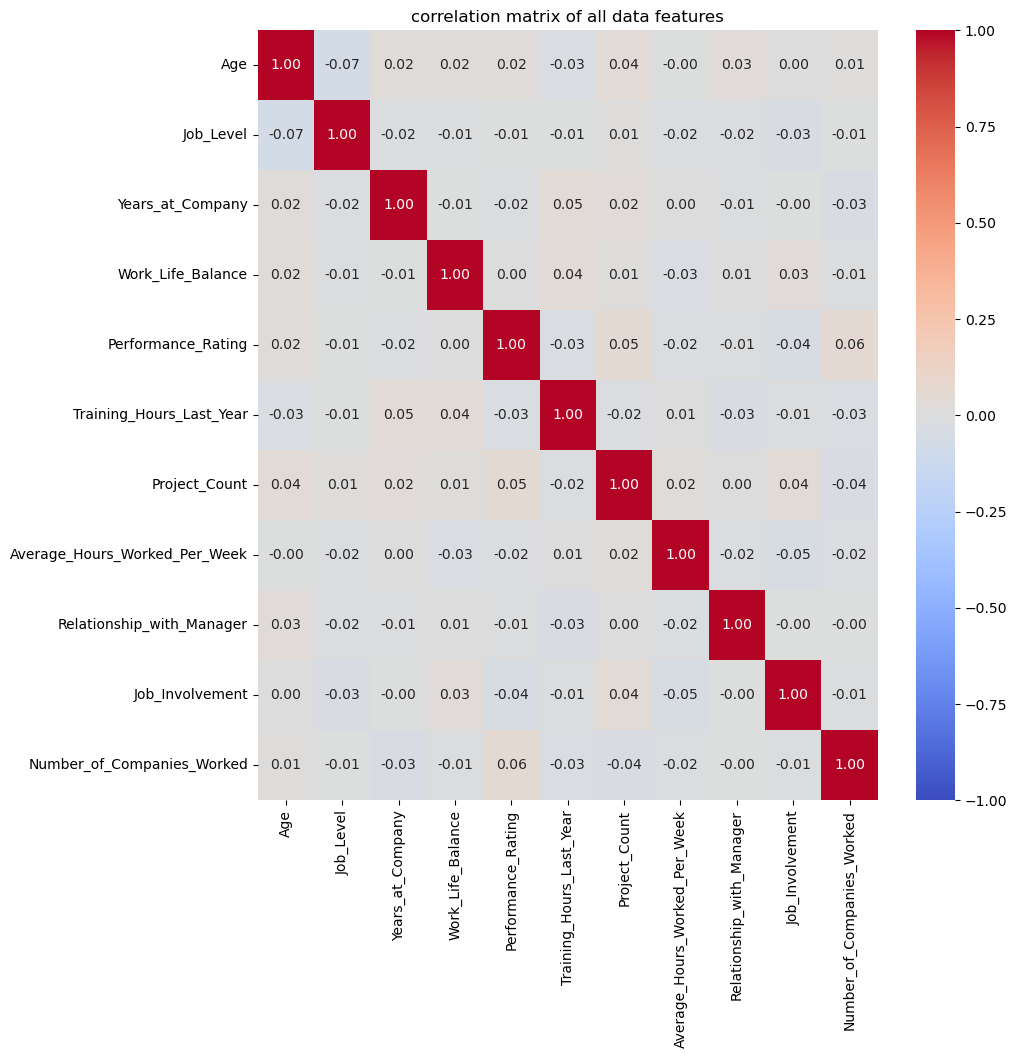

In [49]:
corr_data=data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_data,annot=True,cmap='coolwarm',fmt=".2f",vmin=-1,vmax=1)
plt.title("correlation matrix of all data features")
plt.show()

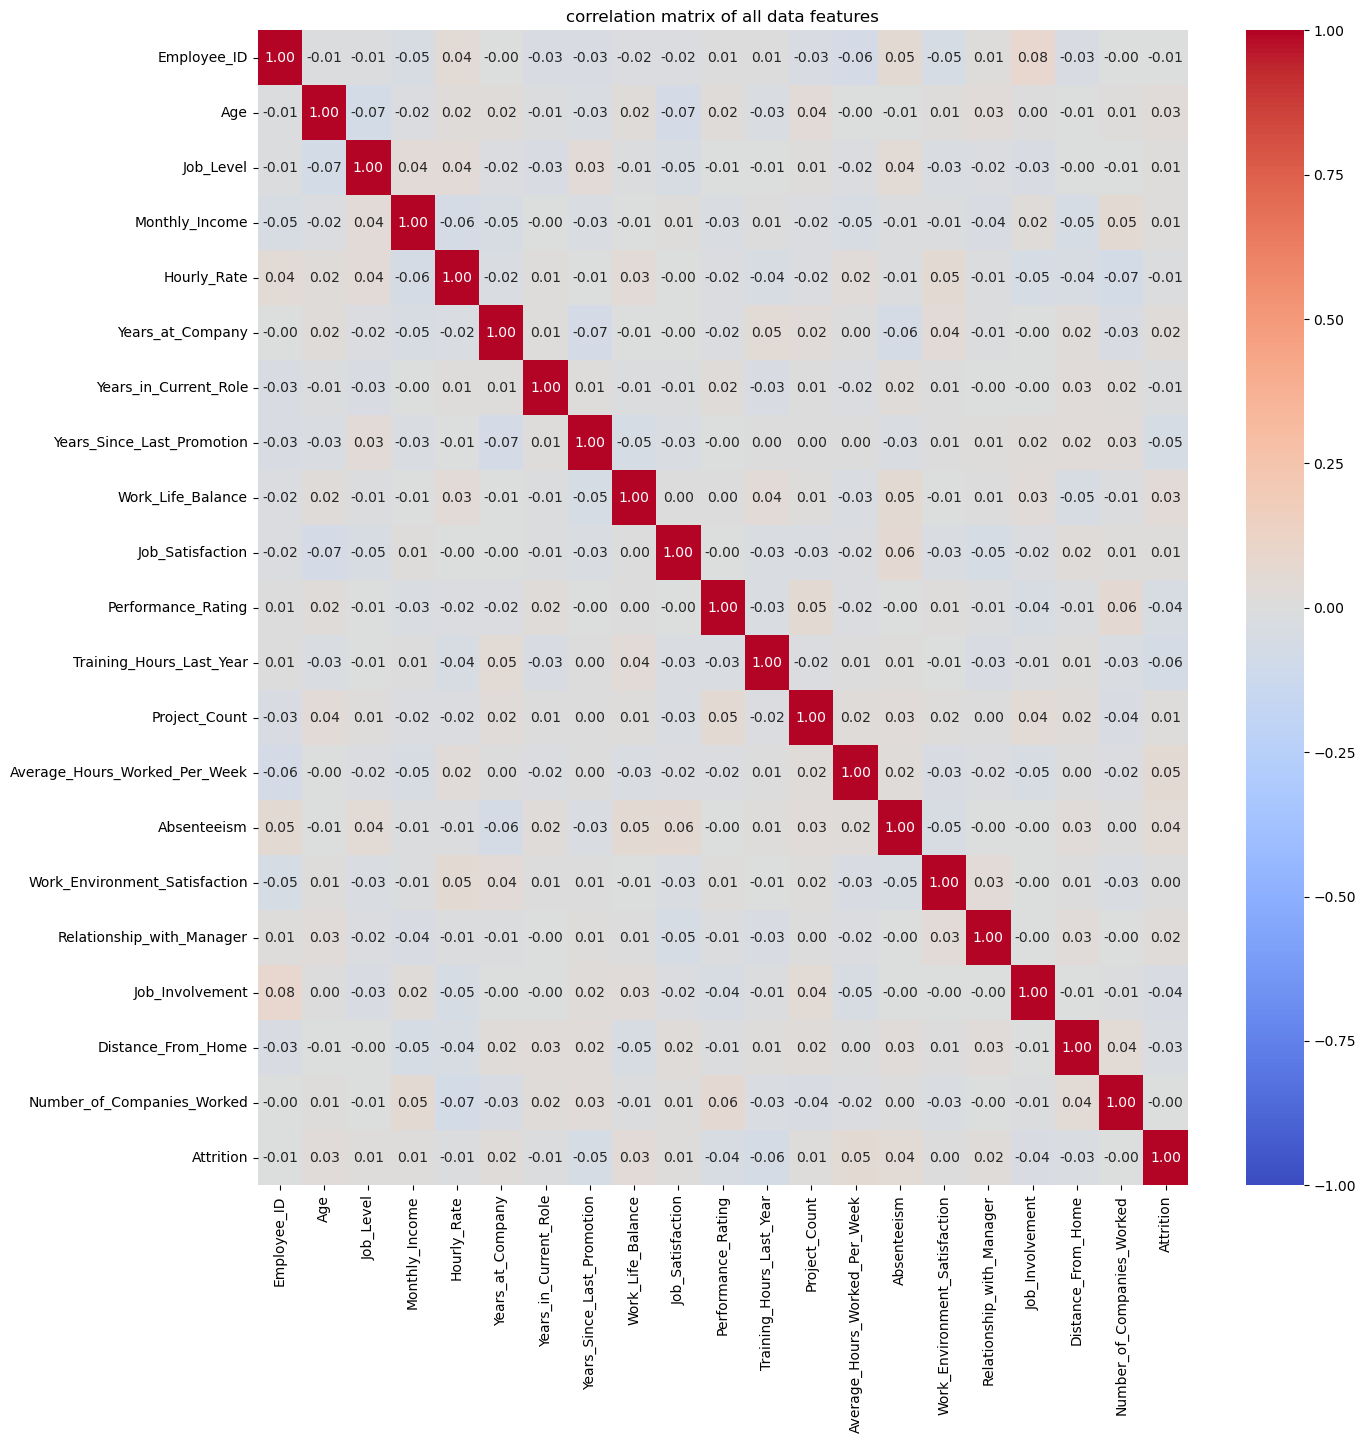

In [62]:
corr_data=datas.corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr_data,annot=True,cmap='coolwarm',fmt=".2f",vmin=-1,vmax=1)
plt.title("correlation matrix of all data features")
plt.show()

### the target value has possitive reation with age,years_at_company,average_hours_worked_per_week,absenteeism,relationship_with_manager
### negative relation with performance_rating,training_hours_last_year,job_involvement,distance_from_home

<Figure size 1000x1000 with 0 Axes>

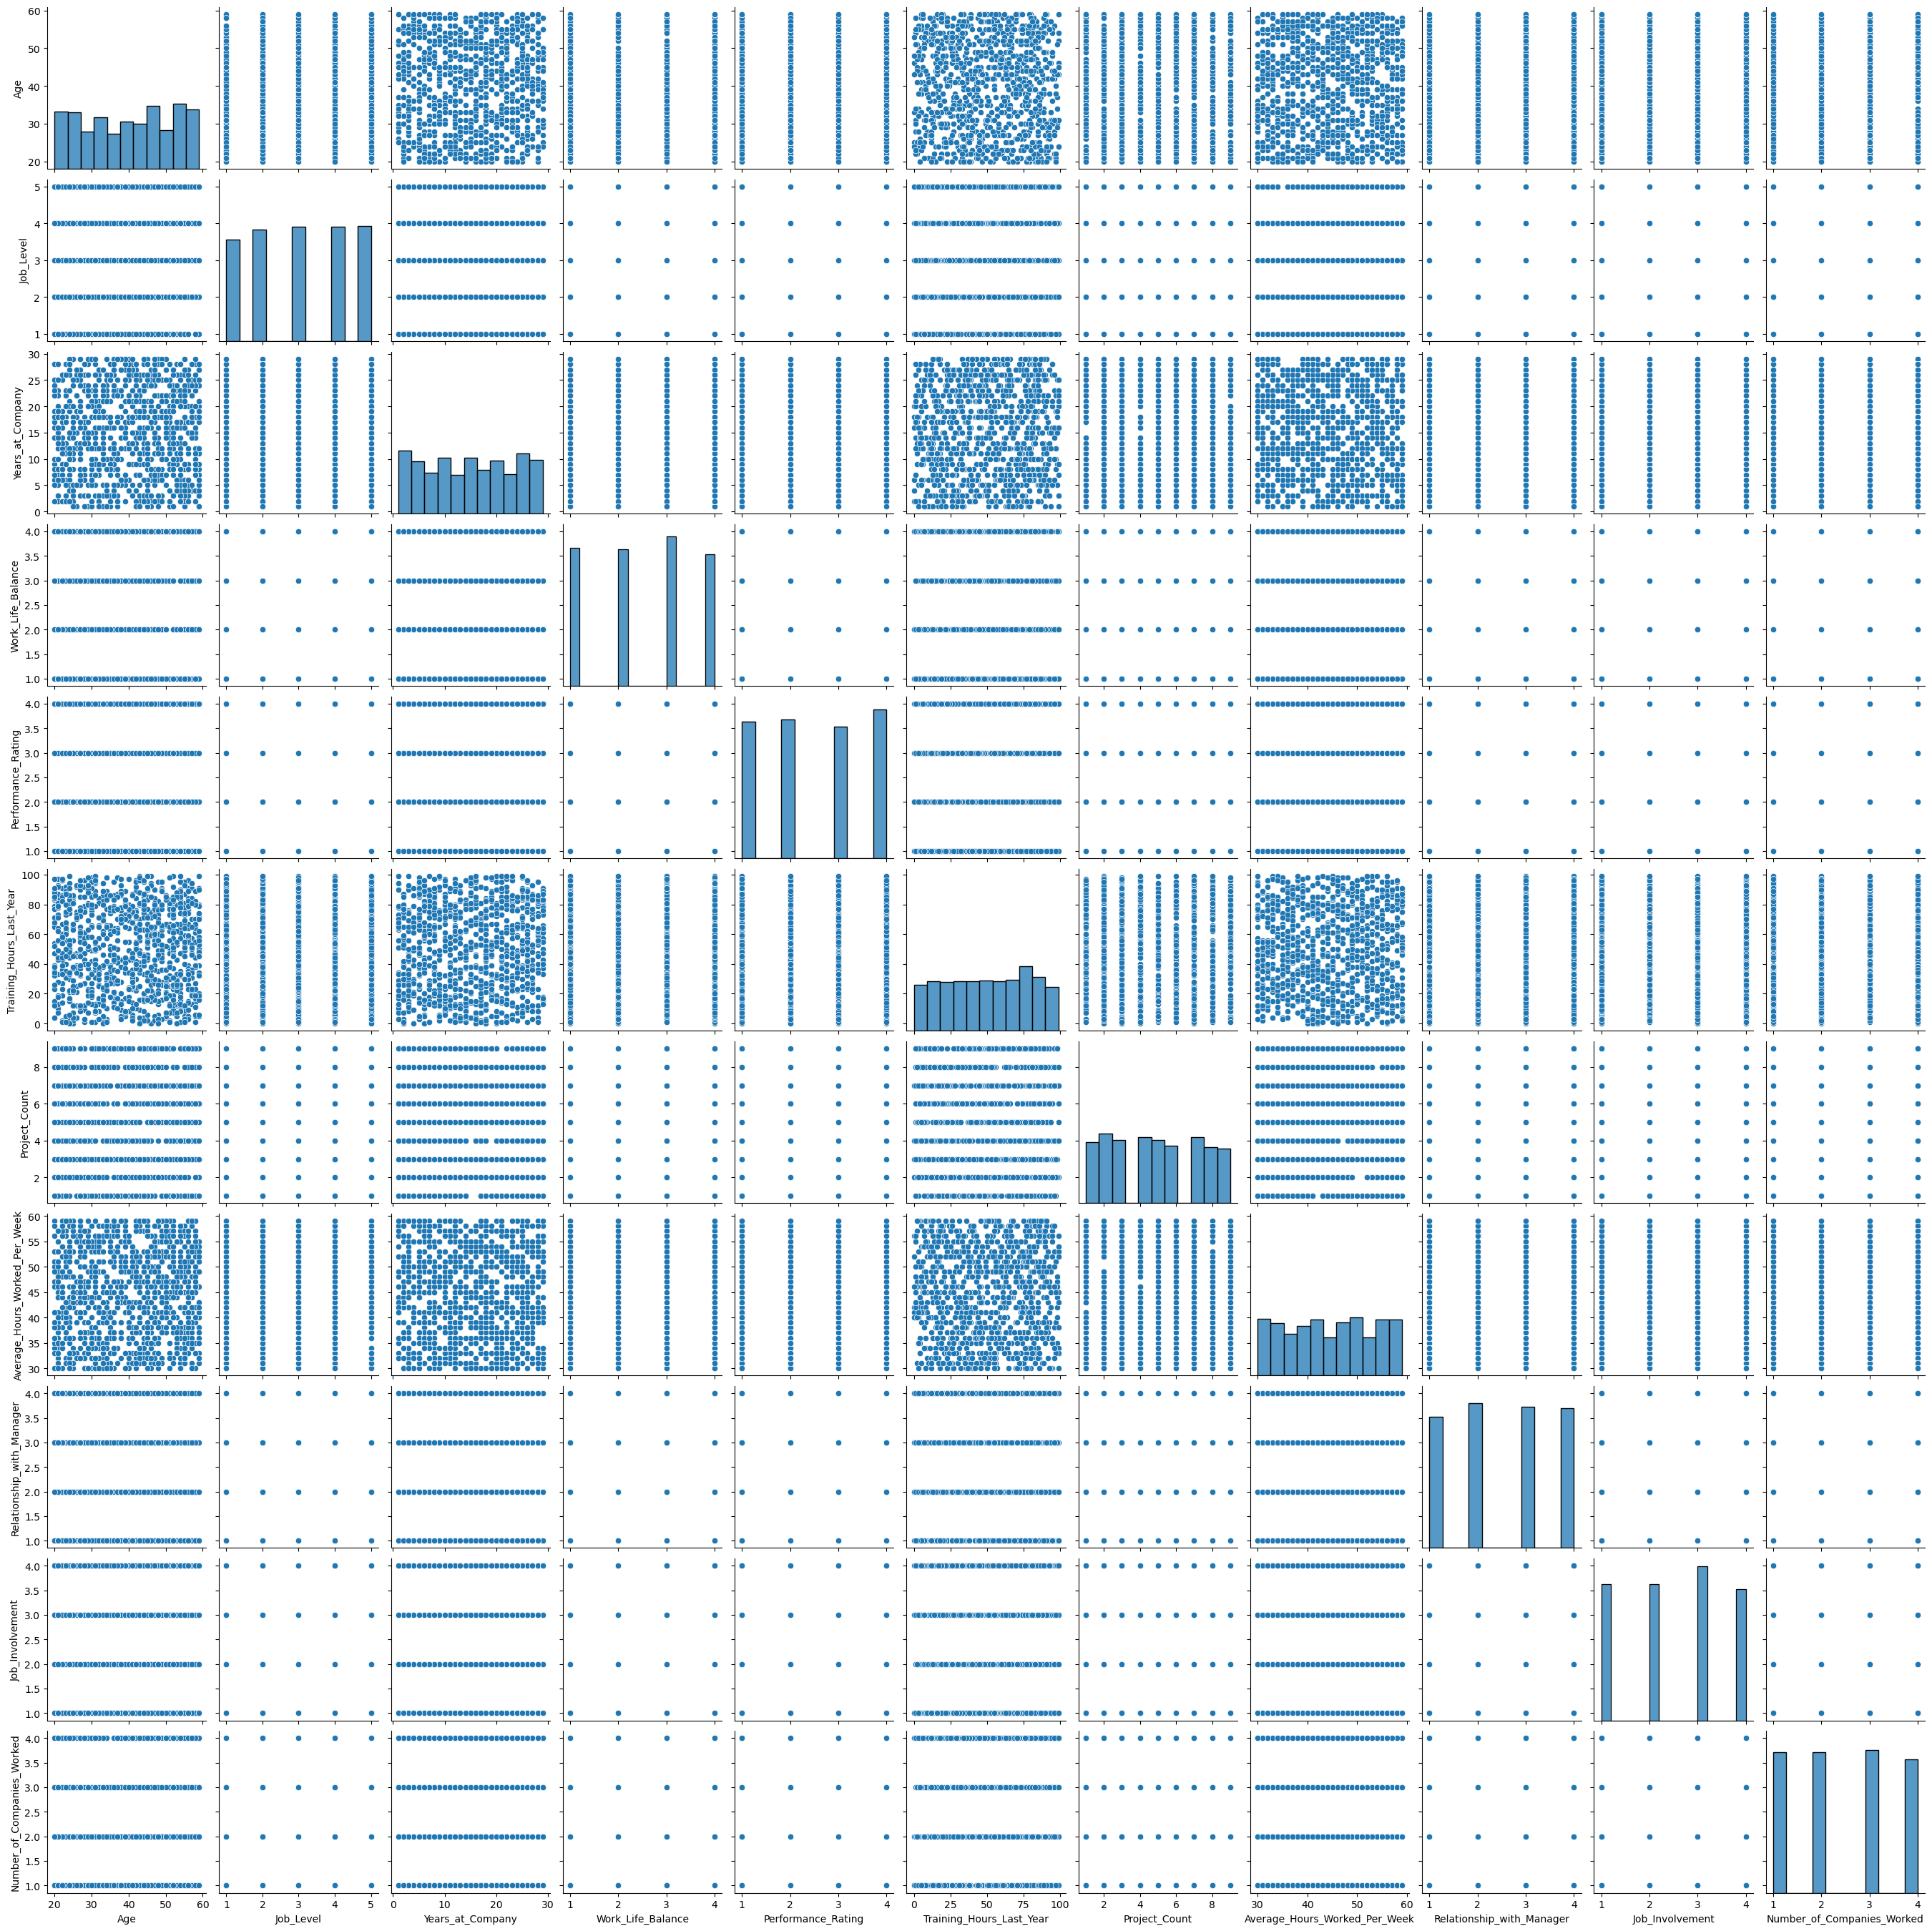

In [53]:
plt.figure(figsize=(10,10))
sns.pairplot(data)
plt.show()

## after observing all the numerical features - we conclude that there is no heteroscedasticity and no skewness exist. 

In [54]:

data = df[['Work_Life_Balance', 'Years_at_Company', 'Training_Hours_Last_Year','Project_Count','Job_Involvement','Number_of_Companies_Worked']]
data

,Work_Life_Balance,Years_at_Company,Training_Hours_Last_Year,Project_Count,Job_Involvement,Number_of_Companies_Worked
0,1,15,14,6,4,3
1,2,6,6,2,2,2
2,3,24,77,6,4,3
3,3,10,49,9,1,3
4,2,29,64,3,3,3
...,...,...,...,...,...,...
995,4,24,76,4,4,4
996,3,19,53,7,4,3
997,4,25,7,1,3,2
998,2,13,54,4,4,4


<Figure size 1000x1000 with 0 Axes>

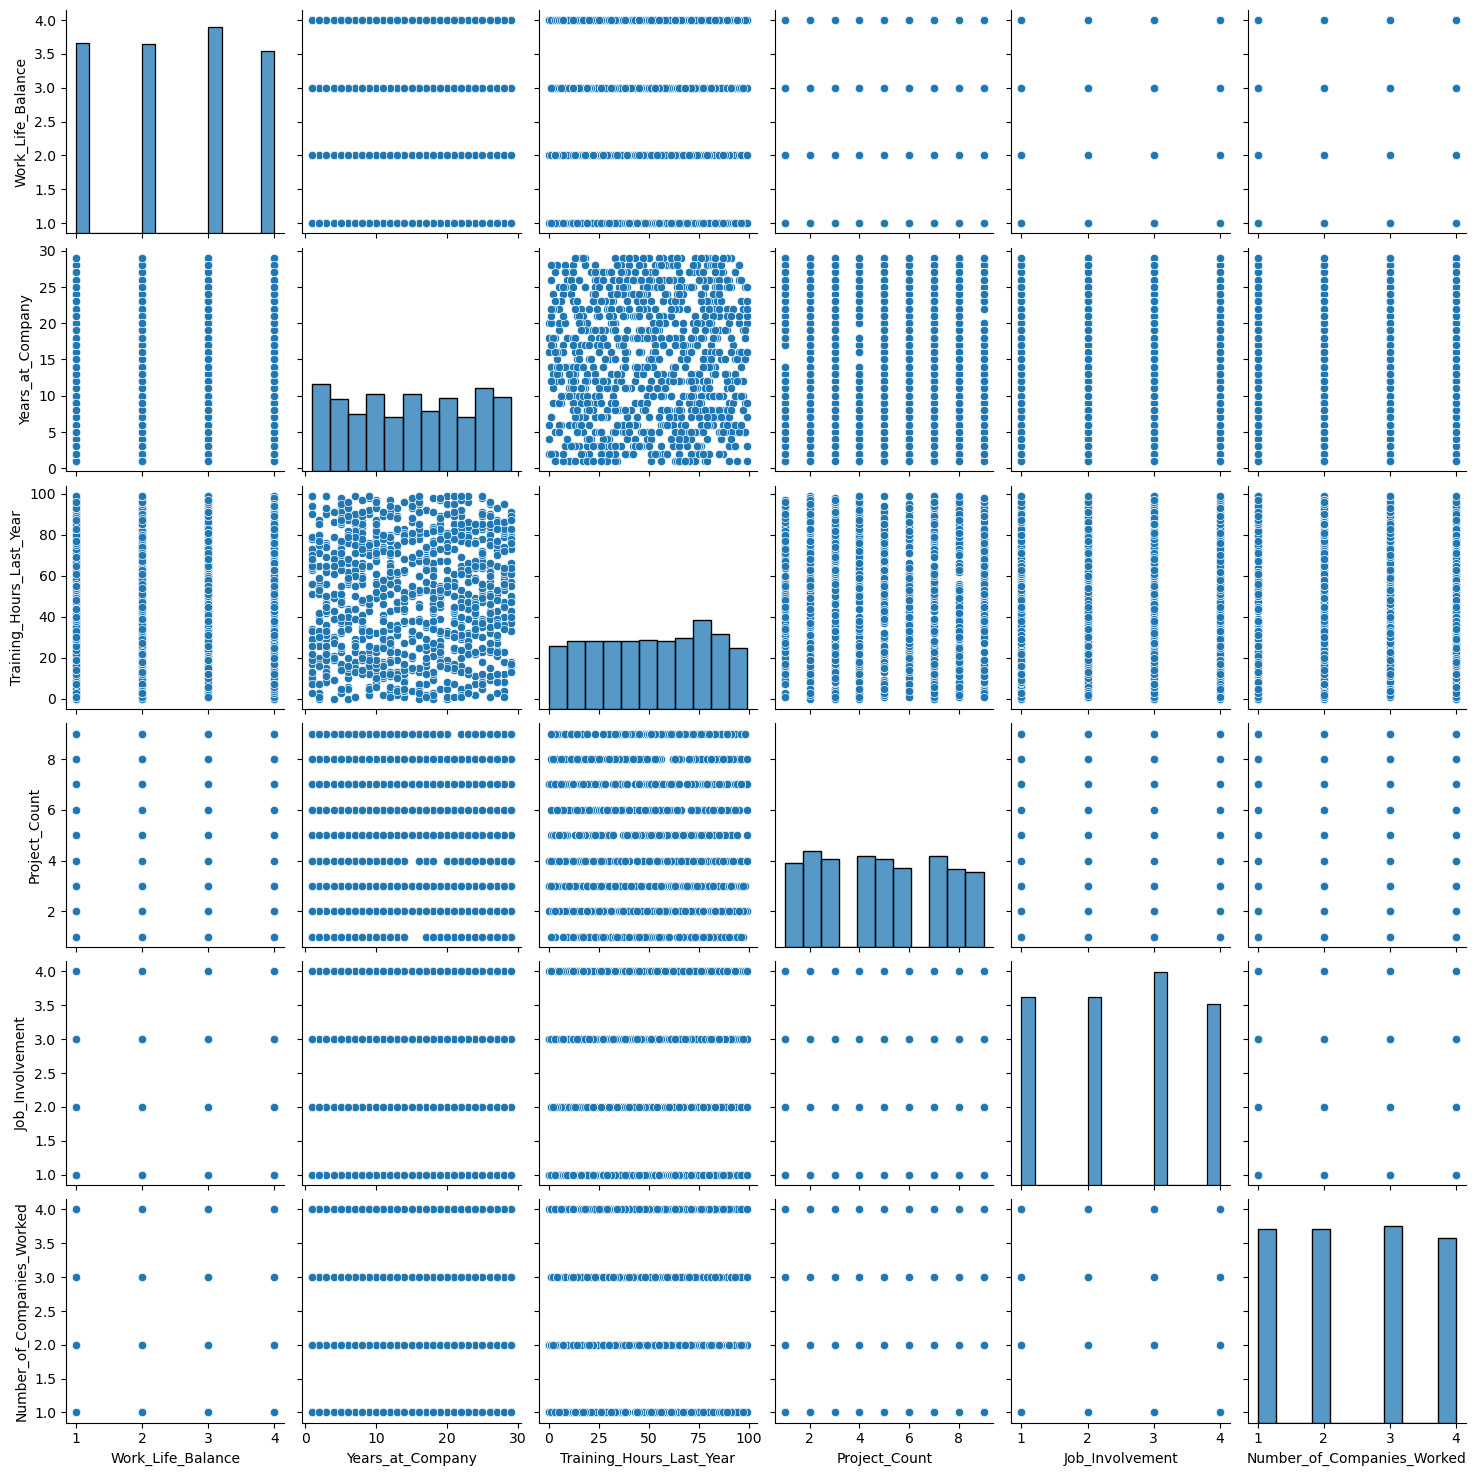

In [55]:
plt.figure(figsize=(10,10))
sns.pairplot(data)
plt.show()

## after observing all the numerical features - we conclude that there is no heteroscedasticity and no skewness exist. 

In [63]:
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# df["Attrition"]=le.fit_transform(df['Attrition'])
df['Attrition']

0      0
1      0
2      0
3      0
4      0
      ..
995    0
996    1
997    0
998    0
999    0
Name: Attrition, Length: 1000, dtype: int64

In [57]:
data = df[['Work_Life_Balance', 'Years_at_Company', 'Training_Hours_Last_Year','Project_Count','Job_Involvement','Number_of_Companies_Worked','Attrition']]
data

,Work_Life_Balance,Years_at_Company,Training_Hours_Last_Year,Project_Count,Job_Involvement,Number_of_Companies_Worked,Attrition
0,1,15,14,6,4,3,0
1,2,6,6,2,2,2,0
2,3,24,77,6,4,3,0
3,3,10,49,9,1,3,0
4,2,29,64,3,3,3,0
...,...,...,...,...,...,...,...
995,4,24,76,4,4,4,0
996,3,19,53,7,4,3,1
997,4,25,7,1,3,2,0
998,2,13,54,4,4,4,0


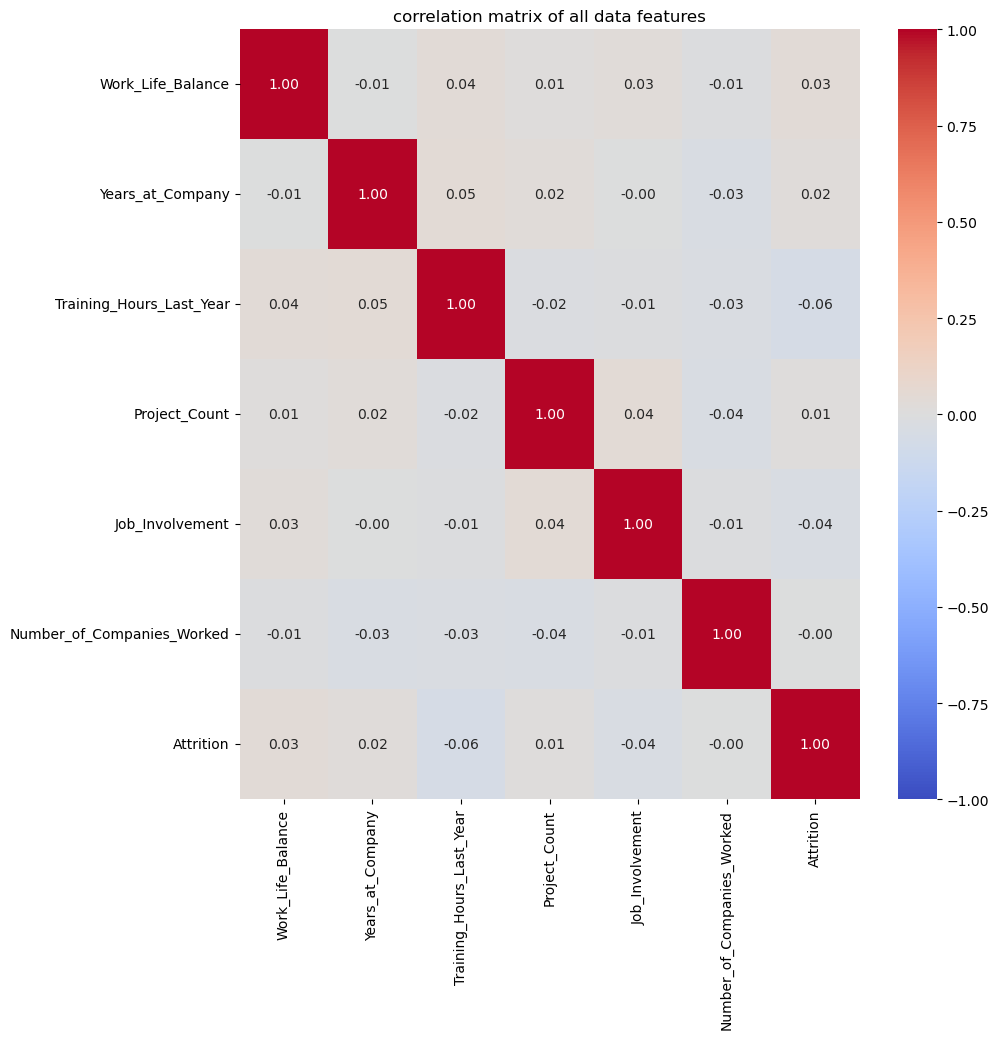

In [58]:
corr_data=data.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_data,annot=True,cmap='coolwarm',fmt=".2f",vmin=-1,vmax=1)
plt.title("correlation matrix of all data features")
plt.show()

In [76]:
datas

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Training_Hours_Last_Year,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,1,15488,28,15,4,2,1,3,...,14,6,54,17,4,4,4,20,3,0
1,2,48,5,13079,28,6,9,1,2,1,...,6,2,45,1,4,1,2,25,2,0
2,3,34,1,13744,24,24,14,8,3,2,...,77,6,34,2,3,4,4,45,3,0
3,4,27,1,6809,26,10,8,2,3,5,...,49,9,48,18,2,3,1,35,3,0
4,5,40,1,10206,52,29,10,1,2,5,...,64,3,33,0,4,1,3,44,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,27,2,4172,76,24,14,3,4,5,...,76,4,46,10,3,1,4,24,4,0
996,997,47,4,11007,71,19,6,0,3,1,...,53,7,36,16,3,2,4,39,3,1
997,998,50,1,4641,43,25,12,3,4,1,...,7,1,46,9,2,3,3,33,2,0
998,999,28,4,19855,92,13,13,0,2,2,...,54,4,52,17,4,1,4,41,4,0


In [77]:
data = df[['Work_Life_Balance', 'Years_at_Company', 'Training_Hours_Last_Year','Project_Count','Job_Involvement','Number_of_Companies_Worked',"Average_Hours_Worked_Per_Week","Absenteeism","Relationship_with_Manager",'Attrition']]
data

,Work_Life_Balance,Years_at_Company,Training_Hours_Last_Year,Project_Count,Job_Involvement,Number_of_Companies_Worked,Average_Hours_Worked_Per_Week,Absenteeism,Relationship_with_Manager,Attrition
0,1,15,14,6,4,3,54,17,4,0
1,2,6,6,2,2,2,45,1,1,0
2,3,24,77,6,4,3,34,2,4,0
3,3,10,49,9,1,3,48,18,3,0
4,2,29,64,3,3,3,33,0,1,0
...,...,...,...,...,...,...,...,...,...,...
995,4,24,76,4,4,4,46,10,1,0
996,3,19,53,7,4,3,36,16,2,1
997,4,25,7,1,3,2,46,9,3,0
998,2,13,54,4,4,4,52,17,1,0


In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

X = data.drop(columns=['Attrition'])

y = data['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("classification report")
print(classification_report(y_test, y_pred))

classification report
              precision    recall  f1-score   support

           0       0.84      1.00      0.92       169
           1       0.00      0.00      0.00        31

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
